# Étude de répartition et de Saisonnalité


## Contexte et objectif

Ce projet analyse la répartition géographique et la saisonnalité des observations de cinq espèces menacées d'Afrique (Éléphant d'Afrique, Lion, Léopard, Guépard, Rhinocéros noir), à partir de données d'occurrence issues de **GBIF** (Global Biodiversity Information Facility).

**Questions posées :**
- Où ces espèces sont-elles le plus fréquemment observées (par pays) ?
- Existe-t-il une saisonnalité dans les observations, et varie-t-elle selon l'espèce ?
- Cette saisonnalité reflète-t-elle un comportement biologique réel ou un biais d'observation (ex. saison touristique) ?

**Source des données :** [GBIF.org](https://www.gbif.org/) - export occurrence sur les 5 espèces ciblées, zone Afrique australe et de l'Est.


In [6]:
import pandas as pd

## 1. Informations sur la base de donnée



In [7]:
df = pd.read_csv("C:/Users/nithi/especes-menacees-afrique/data/raw/especes_menacees.csv", sep='\t', low_memory=False, keep_default_na=False, na_values=[''])
df.head(5)

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,923924124,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/757707,Animalia,Chordata,Mammalia,Proboscidea,Elephantidae,Loxodonta,Loxodonta africana,...,Beranrd Risky Agwanda,2014-06-28T15:18:32,CC_BY_NC_4_0,Beranrd Risky Agwanda,Beranrd Risky Agwanda,NaN,NaN,2026-05-08T21:56:05.290Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
1,911507258,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/727221,Animalia,Chordata,Mammalia,Proboscidea,Elephantidae,Loxodonta,Loxodonta africana,...,Stefano Giannotti,2014-06-09T18:20:31,CC_BY_NC_4_0,Stefano Giannotti,Stefano Giannotti,NaN,NaN,2026-05-08T21:54:59.793Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
2,911507239,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/727233,Animalia,Chordata,Mammalia,Carnivora,Felidae,Panthera,Panthera leo,...,Johnny Wilson,2017-09-12T20:19:41,CC_BY_NC_4_0,Stefano Giannotti,Stefano Giannotti,NaN,NaN,2026-05-08T22:20:02.391Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,911491905,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/532840,Animalia,Chordata,Mammalia,Proboscidea,Elephantidae,Loxodonta,Loxodonta africana,...,J. Allen Ratzlaff,2014-02-16T13:40:07,CC_BY_NC_4_0,J. Allen Ratzlaff,J. Allen Ratzlaff,NaN,NaN,2026-05-08T22:16:32.195Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,911491850,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/526113,Animalia,Chordata,Mammalia,Carnivora,Felidae,Panthera,Panthera pardus,...,Tan Kok Hui,2014-10-10T13:42:36,CC_BY_NC_4_0,J. Allen Ratzlaff,J. Allen Ratzlaff,NaN,NaN,2026-05-08T22:25:51.582Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


In [8]:
df.shape

(31466, 50)

In [9]:
df.columns

Index(['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class',
       'order', 'family', 'genus', 'species', 'infraspecificEpithet',
       'taxonRank', 'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='object')

In [10]:
df.sample(5)

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
22547,3090599427,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/17121844,Animalia,Chordata,Mammalia,Carnivora,Felidae,Panthera,Panthera pardus,...,Luis da Costa,2018-10-02T11:58:53,CC_BY_NC_4_0,David Bygott,David Bygott,NaN,NaN,2026-05-08T21:57:40.351Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
9903,4901706919,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/22382...,Animalia,Chordata,Mammalia,Carnivora,Felidae,Panthera,Panthera pardus,...,Corné Rautenbach,2024-06-19T19:49:48,CC_BY_NC_4_0,Corné Rautenbach,Corné Rautenbach,NaN,NaN,2026-05-08T22:23:36.940Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
27505,2242672674,d45cd682-b4a0-4118-bfc8-eea3fb752aff,NWPB_JP_AJ1079,Animalia,Chordata,Mammalia,Carnivora,Felidae,Acinonyx,Acinonyx jubatus,...,NaN,NaN,CC_BY_4_0,NaN,NaN,NaN,NaN,2026-04-24T09:55:14.811Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;OCCURRENCE_...
11841,4516556587,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/19763...,Animalia,Chordata,Mammalia,Carnivora,Felidae,Panthera,Panthera leo,...,Michal Sloviak,2024-01-27T11:53:53,CC_BY_NC_4_0,Fabrice Prugnaud,Fabrice Prugnaud,NaN,NaN,2026-05-08T22:27:18.281Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
17467,4014933091,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/14598...,Animalia,Chordata,Mammalia,Perissodactyla,Rhinocerotidae,Diceros,Diceros bicornis,...,Guenther Eichhorn,2023-01-07T20:41:20,CC_BY_NC_4_0,dorolexploratrice,dorolexploratrice,NaN,NaN,2026-05-08T22:22:09.659Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


In [11]:
df.isnull().sum()

gbifID                                  0
datasetKey                              0
occurrenceID                         1308
kingdom                                 0
phylum                                  0
class                                   0
order                                   0
family                                  0
genus                                   0
species                                 0
infraspecificEpithet                16201
taxonRank                               0
scientificName                          0
verbatimScientificName                  0
verbatimScientificNameAuthorship    31405
countryCode                             0
locality                            29995
stateProvince                        2747
occurrenceStatus                        0
individualCount                     30125
publishingOrgKey                        0
decimalLatitude                         0
decimalLongitude                        0
coordinateUncertaintyInMeters     

## 2. Préparation et nettoyage des données

On commence par charger le jeu de données brut, l'inspecter, puis ne conserver que les colonnes utiles à l'analyse (espèce, date, coordonnées, pays).


In [12]:
selection_colonnes = ['species', 'eventDate', 'decimalLatitude', 'decimalLongitude', 'countryCode', 'individualCount']
df_clean = df[selection_colonnes]
df_clean.head()

,species,eventDate,decimalLatitude,decimalLongitude,countryCode,individualCount
0,Loxodonta africana,2014-05-19,-3.409340,37.640482,KE,NaN
1,Loxodonta africana,2013-07-01,-2.941302,37.856572,KE,NaN
2,Panthera leo,2013-07-02,-2.943417,37.985066,KE,NaN
3,Loxodonta africana,2012-06-11,-2.276964,34.086782,TZ,NaN
4,Panthera pardus,2012-06-09,-2.475424,34.964466,TZ,NaN


In [13]:
df_clean['individualCount'].isnull().mean()*100

np.float64(95.73825716646539)

In [14]:
df_clean['individualCount'].isnull().sum()

np.int64(30125)

On retire la colonne `individualCount`, quasi entièrement vide (NA), ainsi que les lignes sans `countryCode` exploitable, puis on vérifie que les coordonnées GPS restent dans des plages cohérentes (pas de valeurs (0,0) suspectes).


In [15]:
# Suppression colonne 'IndividualCount' car colonne inutile ne contenant que des NA
df_clean = df_clean.drop(columns=['individualCount'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31466 entries, 0 to 31465
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   species           31466 non-null  object 
 1   eventDate         31466 non-null  object 
 2   decimalLatitude   31466 non-null  float64
 3   decimalLongitude  31466 non-null  float64
 4   countryCode       31466 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.2+ MB


In [16]:
# Afin de savoir si les coordonées GPS sont logique et qu'il n'y a pas d'erreur de saisie (0,0)
print(df_clean[['decimalLatitude', 'decimalLongitude']].describe())

       decimalLatitude  decimalLongitude
count     31466.000000      31466.000000
mean        -16.080905         30.139278
std          11.119852          6.171414
min         -34.790818         12.337586
25%         -25.010758         25.877600
50%         -19.156861         31.596670
75%          -2.853941         35.083925
max           3.148268         40.529200


In [17]:
# Suppression des 2893 NA présents dans Country Code
df_clean = df_clean.dropna(subset=['countryCode'])

print(df_clean['countryCode'].isna().sum())

0


Après correction du chargement (keep_default_na=False), countryCode ne contient plus aucune valeur manquante, car ces valeurs manquantes correspondaient en réalité au countryCode "NA" de la Namibie. Cette ligne ne retire donc aucune ligne, conservée par robustesse et pour expliquer cette difficultée rencontrée.

La Namibie apparaît désormais correctement dans les données (2891 observations), confirmant que la correction du chargement a bien résolu le problème initial.

In [18]:
print(f"Nombre de lignes restantes : {len(df_clean)}")

Nombre de lignes restantes : 31466


In [19]:
# Identification des doublons
df_clean.duplicated(subset=['species', 'eventDate', 'decimalLatitude', 'decimalLongitude']).sum()

np.int64(68)

In [20]:
# Suppression des doublons
df_clean = df_clean.drop_duplicates(subset=['species', 'eventDate', 'decimalLatitude', 'decimalLongitude'])
print(df_clean.shape)

(31398, 5)


In [21]:
# Nature des observations
df['basisOfRecord'].value_counts()

basisOfRecord
HUMAN_OBSERVATION      30271
MACHINE_OBSERVATION     1195
Name: count, dtype: int64

Les MACHINE_OBSERVATION (3,8% du total, probablement des pièges photographiques) n'ont pas le même biais de détection que les observations humaines, un piège photo capture de façon continue, indépendamment de la saison touristique, contrairement à un visiteur.

In [22]:
df['coordinateUncertaintyInMeters'].describe()

count    3.008400e+04
mean     4.457094e+04
std      1.363539e+05
min      1.000000e+00
25%      3.000300e+04
50%      3.059800e+04
75%      3.143800e+04
max      7.313813e+06
Name: coordinateUncertaintyInMeters, dtype: float64

In [23]:
df['coordinateUncertaintyInMeters'].value_counts().head(10)

coordinateUncertaintyInMeters
31446.0    1533
29981.0    1300
28957.0    1225
30598.0    1213
250.0      1150
31451.0    1087
30025.0    1007
31447.0     948
31428.0     882
30003.0     854
Name: count, dtype: int64

In [24]:
mask_cluster = df['coordinateUncertaintyInMeters'].between(28000, 32000)
df.loc[mask_cluster, 'institutionCode'].value_counts()

institutionCode
iNaturalist    25642
Name: count, dtype: int64

In [25]:
df['institutionCode'].value_counts(normalize=True) * 100

institutionCode
iNaturalist               91.301581
NABU|naturgucker           3.868792
North West Parks Board     3.786071
NMK                        0.572683
Anymals.org                0.292705
ADU-UCT                    0.162260
BGBM                       0.015908
Name: proportion, dtype: float64

L'analyse de `coordinateUncertaintyInMeters` révèle qu'une large majorité des observations (plus de 80%) présentent une incertitude de localisation d'environ 28-31 km, concentrée presque exclusivement sur les données issues d'iNaturalist. Ce n'est pas une erreur de mesure : il s'agit du mécanisme de 'geoprivacy' d'iNaturalist, qui obscurcit automatiquement la position réelle des espèces à statut de conservation menacé pour les protéger du braconnage, en substituant un point aléatoire dans une cellule de 0,2° x 0,2°. Ce choix, documenté et volontaire de la part de la plateforme, est particulièrement pertinent pour les 5 espèces de ce projet — toutes des cibles majeures du braconnage.

## 3. Traitement des dates

Les dates source mélangent plusieurs formats. On les convertit en `datetime` (format mixte, en UTC), puis on en extrait l'année et le mois pour permettre l'analyse temporelle.


In [26]:
# Convertir la colonne en format Date
# Utilise les deux format (ISO) et normal ensemble
df_clean['eventDate'] = pd.to_datetime(
    df_clean['eventDate'],
    format='mixed',
    errors='coerce',
    utc=True
)

# Création de la colonne year (année)
df_clean['year'] = df_clean['eventDate'].dt.year

df_clean.head()


,species,eventDate,decimalLatitude,decimalLongitude,countryCode,year
0,Loxodonta africana,2014-05-19 00:00:00+00:00,-3.409340,37.640482,KE,2014.0
1,Loxodonta africana,2013-07-01 00:00:00+00:00,-2.941302,37.856572,KE,2013.0
2,Panthera leo,2013-07-02 00:00:00+00:00,-2.943417,37.985066,KE,2013.0
3,Loxodonta africana,2012-06-11 00:00:00+00:00,-2.276964,34.086782,TZ,2012.0
4,Panthera pardus,2012-06-09 00:00:00+00:00,-2.475424,34.964466,TZ,2012.0


In [27]:
na_count = df_clean['eventDate'].isna().sum()
print(f"Nombre de dates perdues après correction : {na_count}")

Nombre de dates perdues après correction : 11


In [28]:
df_clean.shape

(31398, 6)

In [29]:
# Création de la colonne  month (mois)
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean.head()

,species,eventDate,decimalLatitude,decimalLongitude,countryCode,year,month
0,Loxodonta africana,2014-05-19 00:00:00+00:00,-3.409340,37.640482,KE,2014.0,5.0
1,Loxodonta africana,2013-07-01 00:00:00+00:00,-2.941302,37.856572,KE,2013.0,7.0
2,Panthera leo,2013-07-02 00:00:00+00:00,-2.943417,37.985066,KE,2013.0,7.0
3,Loxodonta africana,2012-06-11 00:00:00+00:00,-2.276964,34.086782,TZ,2012.0,6.0
4,Panthera pardus,2012-06-09 00:00:00+00:00,-2.475424,34.964466,TZ,2012.0,6.0


In [30]:
# Voir la répartition des observations par mois

observations_par_mois = df_clean['month'].value_counts().sort_index()
print(observations_par_mois)

month
1.0     1984
2.0     2073
3.0     1700
4.0     1623
5.0     1917
6.0     2631
7.0     3518
8.0     4199
9.0     3558
10.0    3089
11.0    2883
12.0    2212
Name: count, dtype: int64


## 4. Lisibilité : noms de pays et d'espèces

Les codes pays (ISO) et noms scientifiques latins sont peu lisibles pour une présentation. On les associe à des libellés clairs (ex. `KE` → Kenya, `Panthera leo` → Lion) pour faciliter les graphiques et leurs interprétations.


In [31]:
# Renommer les noms des pays dans countryCode

mapping_pays = {
    'KE': 'Kenya',
    'TZ': 'Tanzanie',
    'ZA': 'Afrique du Sud',
    'NA': 'Namibie',
    'BW': 'Botswana',
    'ZW': 'Zimbabwe',
}

# Creation de la nouvelle colonne 'coutry-name'

df_clean['country_name'] = df_clean['countryCode'].map(mapping_pays)

# Vérification

print(df_clean[['countryCode', 'country_name']].sample(5))


      countryCode    country_name
12172          ZA  Afrique du Sud
20689          KE           Kenya
11797          KE           Kenya
16727          TZ        Tanzanie
5161           ZA  Afrique du Sud


In [32]:
# Renommer le nom des espèces dans 'species'

mapping_species = {
    'Loxodonta africana' : 'Éléphant d\'Afrique',
    'Panthera leo' : 'Lion',
    'Panthera pardus' : 'Léopard',
    'Acinonyx jubatus' : 'Guépard',
    'Diceros bicornis' : 'Rhinocéros noir'
}

df_clean['Nom_espèces'] = df_clean['species'].map(mapping_species)

df_clean.head(5)


,species,eventDate,decimalLatitude,decimalLongitude,countryCode,year,month,country_name,Nom_espèces
0,Loxodonta africana,2014-05-19 00:00:00+00:00,-3.409340,37.640482,KE,2014.0,5.0,Kenya,Éléphant d'Afrique
1,Loxodonta africana,2013-07-01 00:00:00+00:00,-2.941302,37.856572,KE,2013.0,7.0,Kenya,Éléphant d'Afrique
2,Panthera leo,2013-07-02 00:00:00+00:00,-2.943417,37.985066,KE,2013.0,7.0,Kenya,Lion
3,Loxodonta africana,2012-06-11 00:00:00+00:00,-2.276964,34.086782,TZ,2012.0,6.0,Tanzanie,Éléphant d'Afrique
4,Panthera pardus,2012-06-09 00:00:00+00:00,-2.475424,34.964466,TZ,2012.0,6.0,Tanzanie,Léopard


In [33]:
# Compte le nombre d'observations par espèce
stats_especes = df_clean['Nom_espèces'].value_counts()
print(stats_especes)

Nom_espèces
Éléphant d'Afrique    13394
Lion                   8970
Guépard                3864
Léopard                3769
Rhinocéros noir        1401
Name: count, dtype: int64


## 5. Répartition des observations par espèce

Combien d'observations compte-t-on pour chaque espèce dans le jeu de données ? Cela donne un premier aperçu de la représentativité de chaque espèce dans l'échantillon (et donc des limites à garder en tête : une espèce sous-représentée n'est pas nécessairement plus rare, elle peut être moins suivie).


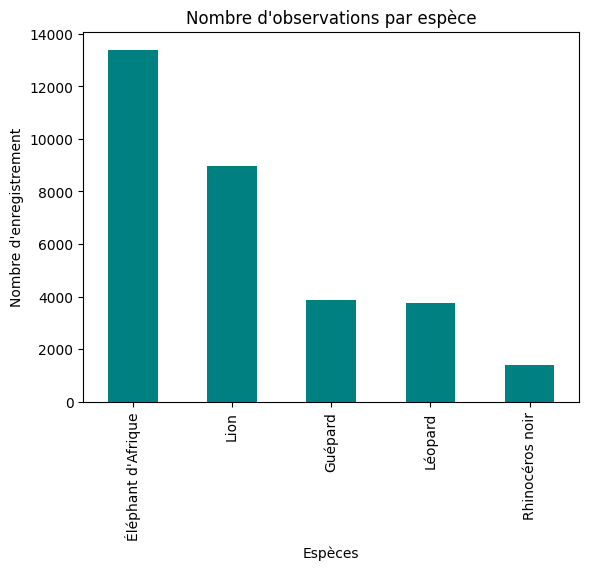

In [34]:
import matplotlib.pyplot as plt

# Visualisation du nombre d'observations par espèces

stats_especes.plot(kind='bar', color ='teal', title='Nombre d\'observations par espèce')
plt.xlabel('Espèces')
plt.ylabel('Nombre d\'enregistrement')
plt.show()

Les éléphants d'Afrique sont l'espèce la plus représentée avec 13 394 observations, suivis par les lions (8970), puis les guépards (3864) et les léopards (3769), ces deux derniers étant quasiment à égalité. Les rhinocéros noirs (1401) sont nettement en retrait, avec un écart important par rapport aux quatre autres espèces.

Cet écart ne reflète pas nécessairement une hiérarchie de rareté biologique inversée. Le rhinocéros noir est effectivement l'espèce la plus menacée des cinq (classé en danger critique d'extinction par l'UICN, avec une population mondiale de quelques milliers d'individus, contre plusieurs centaines de milliers pour l'éléphant d'Afrique). Mais il se superpose probablement à un second facteur, qui a été documenté en section 2 : le mécanisme d'obscurcissement géographique d'iNaturalist cible en priorité les espèces à statut de conservation critique, précisément pour les protéger du braconnage. Le rhinocéros noir, cible historique majeure du braconnage pour sa corne, est susceptible d'être à la fois réellement plus rare et plus systématiquement obscurci ou sous-signalé que les autres espèces, les deux effets se cumulent et sont plausibles sans qu'on puisse les séparer avec les seules données disponibles ici.

## 6. Répartition géographique par pays

On regarde maintenant dans quels pays les observations sont concentrées. Cela permet d'identifier les zones d'effort d'observation (souvent corrélées aux parcs nationaux et zones touristiques) plutôt qu'une distribution purement biologique des espèces.


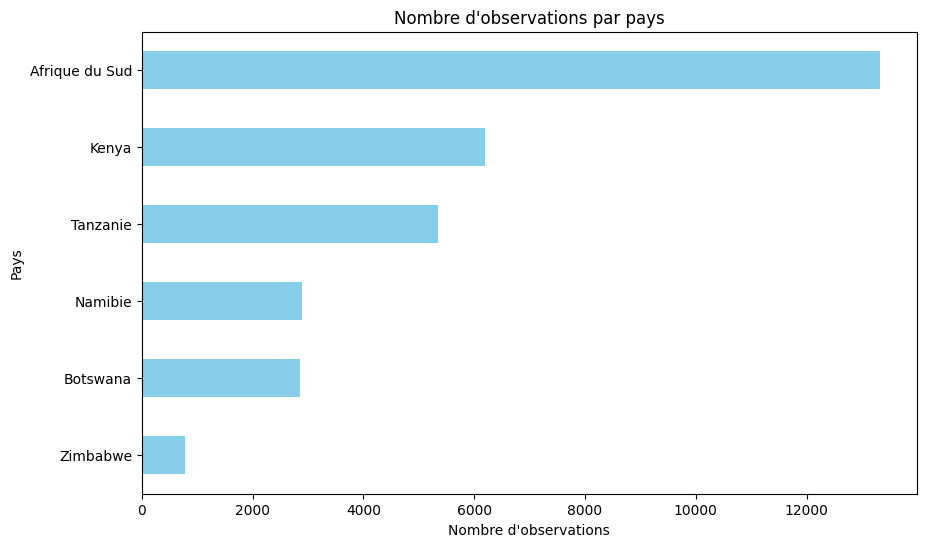

In [35]:
# Visualisation observations par pays

#Compter les observations par pays
stats_pays = df_clean['country_name'].value_counts()

#Visualisation

plt.figure(figsize=(10,6))
stats_pays.plot(kind='barh', color='skyblue')

plt.title('Nombre d\'observations par pays')
plt.xlabel('Nombre d\'observations')
plt.ylabel('Pays')
plt.gca().invert_yaxis() # Pour avoir le plus grand en haut
plt.show()

In [36]:
print(stats_pays)

country_name
Afrique du Sud    13322
Kenya              6198
Tanzanie           5340
Namibie            2891
Botswana           2862
Zimbabwe            785
Name: count, dtype: int64


L'Afrique du Sud concentre à elle seule un peu plus de 42% des observations (13 322), loin devant le Kenya (6198) et la Tanzanie (5340). La Namibie (2891) et le Botswana (2862) se situent à un niveau comparable, en retrait net par rapport au trio de tête. Le Zimbabwe (785) est le pays le plus sous-représenté, avec un écart marqué par rapport aux cinq autres.

Cette hiérarchie ne s'explique pas uniquement par la superficie ou le nombre de parcs nationaux (l'Afrique du Sud, la Namibie et le Botswana ont des superficies comparables, mais des niveaux d'observation très différents). Un facteur probablement au moins aussi déterminant est l'infrastructure touristique et la densité de contributeurs actifs sur les plateformes de sciences participatives comme iNaturalist (cf. section 2) : l'Afrique du Sud dispose d'un tourisme safari particulièrement développé et d'une communauté de contributeurs établie, tandis que des pays comme le Zimbabwe ont traversé une instabilité économique et politique prolongée (Coup d'État de novembre 2017) qui a pu freiner à la fois le tourisme et indirectement, le volume d'observations rapportées, indépendamment de la présence réelle des espèces sur leur territoire.

In [37]:
!pip install folium

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.6 MB 5.0 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.6 MB 5.8 MB/s eta 0:00:02
   ----------- ---------------------------- 3.7/12.6 MB 5.7 MB/s eta 0:00:02
   --------------- ------------------------ 5.0/12.6 MB 5.9 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.6 MB 5.9 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.6 MB 6.0 MB/s eta 0:00:01
   --------------------------- ------------ 8.7/12.6 MB 5.9 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 6.0 MB/s eta 0:00:01
   ----------------------------------- ---- 11.3/12.6 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------

In [40]:
%pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached xyzservices-2026.9.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached xyzservices-2026.9.1-py3-none-any.whl (98 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)
Using cached idna-3.20-py3-none-any.whl (69 kB)
Using cached urllib3-2.8.0-py3-none-any.whl (135 kB)
Note: you may need to restart the kernel to us


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 7. Cartographie des observations

Pour visualiser la dimension spatiale, on place chaque observation sur une carte interactive (Folium), regroupée par clusters pour rester lisible malgré le volume de points.

In [41]:
import folium
from folium.plugins import MarkerCluster

# Création d'une carte centrée sur l'Afrique (Sud/Est)
carte = folium.Map(location=[-20, 25], zoom_start=4, tiles="Esri.WorldStreetMap")

# Créer un groupe de points (Cluster)
marker_cluster = MarkerCluster().add_to(carte)

# Ajout des points
for idx, row in df_clean.iterrows():
  folium.Marker(
      location=[row['decimalLatitude'], row['decimalLongitude']],
      popup = f"Espèce: {row['Nom_espèces']}\nPays: {row['country_name']}",
  ).add_to(marker_cluster)

# Affichage de la carte
carte.save("../visualisation/carte_especes_afrique.html")

Cette carte intéractive présente la concentration des observations effectuées afin d'identifier les principaux zones d'observations de ses espèces pouvant correspondre comme mentionné plus haut à des zones où sont présentes des grands parc nationaux.

Cependant, la carte doit donc être interprétée comme une répartition par zone approximative plutôt qu'un pointage précis des observations, une limite inhérente à la nature protectrice des données plutôt qu'à un défaut de nettoyage.

## 8. Évolution annuelle

**Lecture du graphique :** on observe ici si le nombre d'observations augmente, diminue ou reste stable d'une année sur l'autre. Une variation forte peut autant refléter un changement réel de présence des espèces qu'une évolution de l'effort d'observation (ex. plus de relevés GBIF récents).


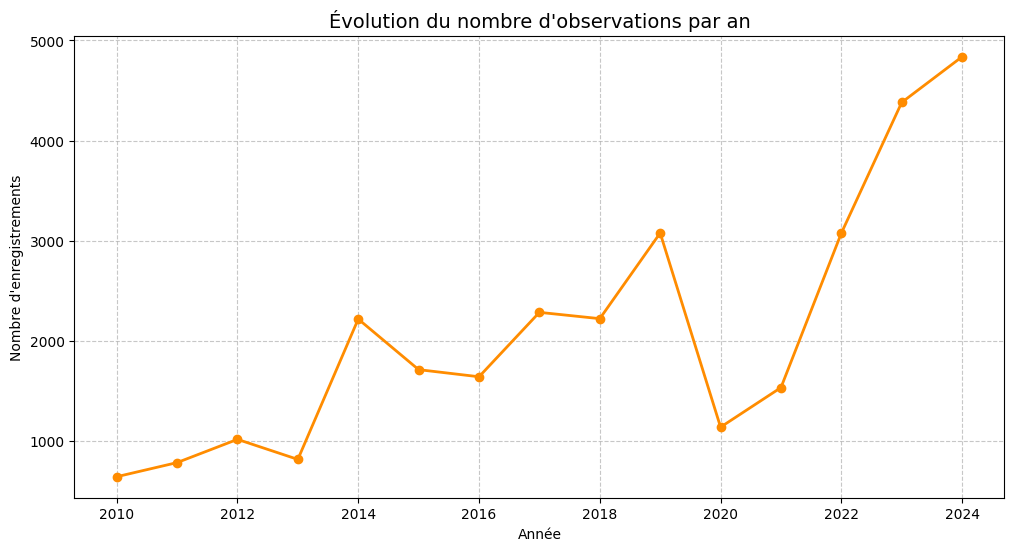

In [42]:
# Compter les observations par année et trier par ordre chronologique
evolution_annuelle = df_clean['year'].value_counts().sort_index()

# Création d'un graphique linéaire (Line Plot)
plt.figure(figsize=(12, 6))
evolution_annuelle.plot(kind='line', marker='o', color='darkorange', linewidth=2)

plt.title('Évolution du nombre d\'observations par an', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Nombre d\'enregistrements')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [43]:
print(evolution_annuelle)

year
2010.0     644
2011.0     785
2012.0    1017
2013.0     817
2014.0    2218
2015.0    1713
2016.0    1642
2017.0    2285
2018.0    2222
2019.0    3077
2020.0    1139
2021.0    1534
2022.0    3076
2023.0    4381
2024.0    4837
Name: count, dtype: int64


On remarque que les observations augmentent avec le temps, avec une chute nette en 2020 correspondant à la période du COVID (1139 observations, contre 3077 en 2019). La croissance s'accélère très largement à partir de 2022 (3076 → 4381 → 4837), plus probablement liée à l'essor des plateformes de sciences participatives elles-mêmes (le nombre de contributeurs actifs sur iNaturalist a fortement augmenté sur cette période) qu'à un changement réel dans la présence des espèces.

## 9. La Saisonnalité

**Lecture du graphique :** cette vue agrège toutes les espèces. Avant de conclure à une saisonnalité biologique (migrations, reproduction), il faut comparer avec le graphique suivant, qui détaille par espèce. Un pic global peut être tiré par une seule espèce très observée plutôt que par un phénomène partagé.


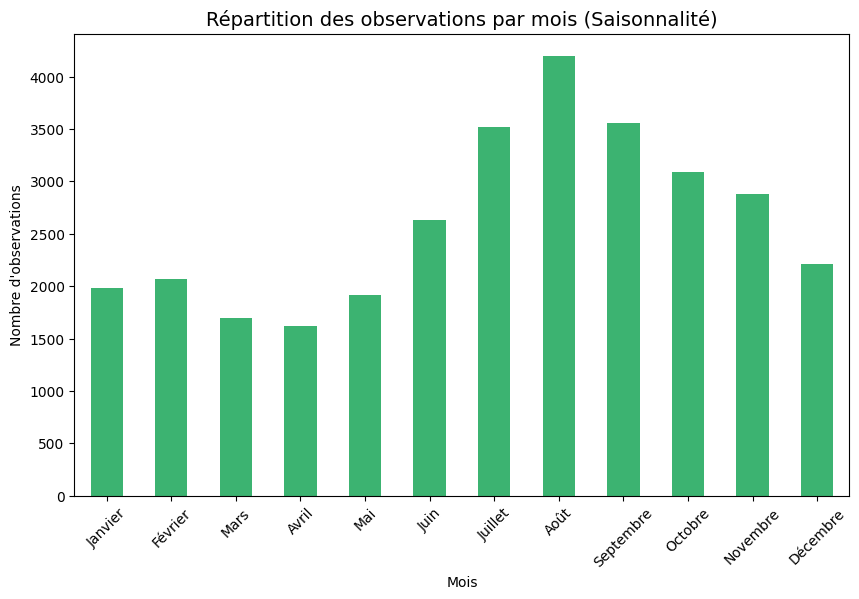

In [44]:
# Compter les observations par mois
evolution_mensuelle = df_clean['month'].value_counts().sort_index()

# Créer un graphique à barres pour les mois
plt.figure(figsize=(10, 6))
evolution_mensuelle.plot(kind='bar', color='mediumseagreen')

# Remplacer les chiffres 1-12 par les noms des mois pour la lisibilité
plt.xticks(range(0, 12), ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre'], rotation=45)

plt.title('Répartition des observations par mois (Saisonnalité)', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Nombre d\'observations')
plt.show()


Les mois où les observations sont les plus élevées correspondent à la période juillet-septembre, coïncidant avec la saison sèche est-africaine et la haute saison touristique des safaris, période où le nombre de visiteurs est le plus élevé.

## 10. Saisonnalité par Espèce

**Lecture du graphique :** en détaillant par espèce, on peut distinguer une saisonnalité propre à chaque animal d'un simple effet de volume. À interpréter avec prudence : les données GBIF sont déclaratives et dépendent fortement de la fréquentation touristique (ex. pic en saison sèche est-africaine, qui coïncide avec la haute saison des safaris).


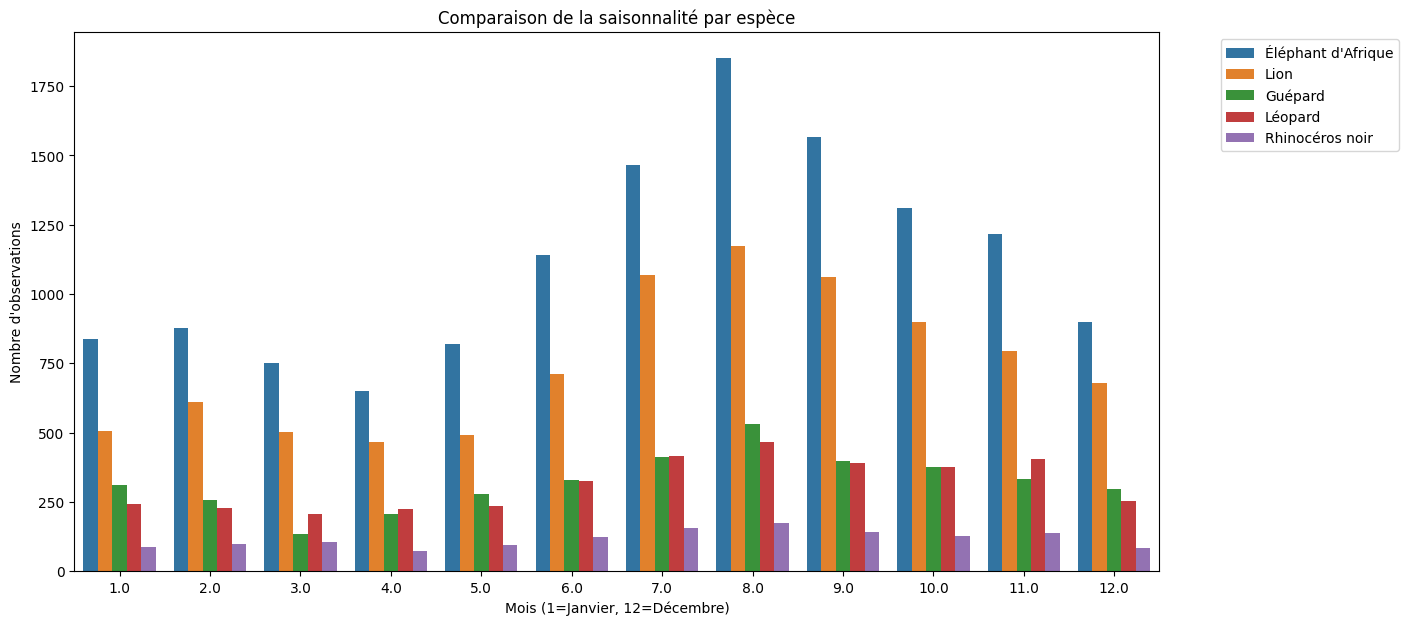

In [45]:
import seaborn as sns

# Créer un graphique qui montre les mois pour chaque espèce
plt.figure(figsize=(14, 7))
sns.countplot(data=df_clean, x='month', hue='Nom_espèces')
plt.title('Comparaison de la saisonnalité par espèce')
plt.xlabel('Mois (1=Janvier, 12=Décembre)')
plt.ylabel('Nombre d\'observations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Les 5 espèces présentent une saisonnalité quasi identique, avec un pic marqué entre juillet et septembre. Cette synchronisation suggère que la courbe reflète davantage l'intensité de l'effort d'observation, concentré sur la haute saison touristique des safaris (saison sèche, vacances d'été dans l'hémisphère nord), qu'un véritable comportement saisonnier biologique spécifique à chaque espèce.

In [46]:
# Normalisation par espèces :
saisonnalite_especes = df_clean.groupby(['month', 'Nom_espèces']).size().unstack(fill_value=0)

saisonnalite_pct = saisonnalite_especes.div(saisonnalite_especes.sum(axis=0), axis=1) * 100
print(saisonnalite_pct.round(1))

Nom_espèces  Guépard  Lion  Léopard  Rhinocéros noir  Éléphant d'Afrique
month                                                                   
1.0              8.0   5.6      6.5              6.1                 6.3
2.0              6.7   6.8      6.1              7.1                 6.5
3.0              3.5   5.6      5.5              7.5                 5.6
4.0              5.4   5.2      6.0              5.1                 4.9
5.0              7.2   5.5      6.2              6.7                 6.1
6.0              8.5   8.0      8.6              8.9                 8.5
7.0             10.7  11.9     11.0             11.1                10.9
8.0             13.7  13.1     12.4             12.4                13.8
9.0             10.3  11.9     10.3             10.1                11.7
10.0             9.7  10.0     10.0              9.0                 9.8
11.0             8.6   8.8     10.7              9.9                 9.1
12.0             7.7   7.6      6.7              6.

La normalisation par espèce (% du total annuel) confirme que la saisonnalité est quasi identique d'une espèce à l'autre : le trimestre juillet-septembre concentre entre 33,5% et 36,5% du total annuel de chaque espèce, avec un pic en août très homogène (12,4% à 13,8% selon l'espèce). Cette synchronisation, observée sur des espèces aux modes de vie pourtant différents, renforce l'hypothèse que la courbe reflète principalement l'intensité de l'effort d'observation touristique (haute saison safari, saison sèche) plutôt qu'un comportement biologique saisonnier propre à chaque animal.

# 11. Conclusion et limites du projet

**Principaux constats :**
- Les observations sont concentrées dans un nombre restreint de pays, l'Afrique du Sud en tête (42% du total), cohérent avec son infrastructure touristique et sa communauté de contributeurs développées plutôt qu'avec la seule superficie des pays.
- Une saisonnalité apparaît dans les observations, mais elle est difficile à attribuer avec certitude à un comportement biologique plutôt qu'à un effet de fréquentation touristique.
- La répartition entre espèces dans l'échantillon n'est pas homogène, ce qui limite les comparaisons directes entre elles.

**Limites du jeu de données :**
- Les données GBIF sont des données d'occurrence citoyennes/scientifiques, pas un recensement exhaustif : elles reflètent l'effort d'observation autant que la présence réelle des espèces.
- Aucune donnée de comptage de population n'est disponible (colonne `individualCount` quasi vide), donc l'analyse porte sur le nombre d'observations, pas sur les effectifs réels.
- Pas de croisement avec des données climatiques ou de fréquentation touristique pour confirmer/infirmer l'hypothèse de biais saisonnier.

**Pistes d'amélioration :**
- Croiser avec des données de saisonnalité touristique par pays pour isoler le biais d'observation.
- Requêtes SQL sur la base exportée (cohortes, évolution par pays).
- Modèle de prédiction simple de la probabilité d'observation par mois/région.
